# Netflix Audience Rating Classification

## Project Overview

This project focuses on building a machine learning classification model to predict the audience rating category of Netflix content using available content attributes.

The project includes data analysis, preprocessing, feature engineering, classification model training, hyperparameter optimization, and performance evaluation.

The main objective is to compare multiple machine learning models and identify the most suitable model for predicting Netflix audience rating categories.

## 2. Import Required Libraries

### Description

In this step, we import the required Python libraries for developing the Netflix Audience Rating Classification model.

Pandas and NumPy are used for data manipulation and numerical operations. Matplotlib and Seaborn support data visualization and exploratory analysis. Scikit-learn provides the machine learning tools required for data preprocessing, model training, hyperparameter optimization, and evaluation.

These libraries will help us build an efficient and reliable classification workflow.

In [2]:
# Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler,
    OneHotEncoder
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


## 3. Load the Netflix Dataset

### Description

In this step, the Netflix dataset is loaded from the specified CSV file path using Pandas.

After loading the dataset, we perform an initial inspection to verify that the data has been imported correctly. The first few records, dataset dimensions, and available column names are displayed to understand the structure of the data before proceeding with preprocessing and analysis.

In [3]:
# Load the Netflix dataset

df = pd.read_csv("../Data/netflix_titles.csv")

# Display the first five records
print("First 5 records:")
display(df.head())

# Display dataset dimensions
print("\nDataset Shape:")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

# Display column names
print("\nColumn Names:")
print(df.columns.tolist())

First 5 records:


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"



Dataset Shape:
Rows: 8790
Columns: 10

Column Names:
['show_id', 'type', 'title', 'director', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in']


In [4]:
# Analyze audience rating categories

print("Unique Rating Categories:")
print(df["rating"].unique())

print("\nNumber of Rating Categories:")
print(df["rating"].nunique())

print("\nRating Category Distribution:")
print(df["rating"].value_counts(dropna=False))

print("\nMissing Rating Values:")
print(df["rating"].isna().sum())

Unique Rating Categories:
<StringArray>
[   'PG-13',    'TV-MA',    'TV-PG',    'TV-14',    'TV-Y7',     'TV-Y',
       'PG',     'TV-G',        'R',        'G',    'NC-17',       'NR',
 'TV-Y7-FV',       'UR']
Length: 14, dtype: str

Number of Rating Categories:
14

Rating Category Distribution:
rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

Missing Rating Values:
0


## 4. Analyze Audience Rating Categories

### Description

In this step, we analyze the audience rating categories available in the Netflix dataset.

The rating column represents the audience classification assigned to each Netflix title. We examine the unique rating categories and their frequency to understand the distribution of the target variable.

This analysis helps identify common and less frequent rating categories and provides an initial understanding of the classification problem.

Rating Category Distribution:


rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

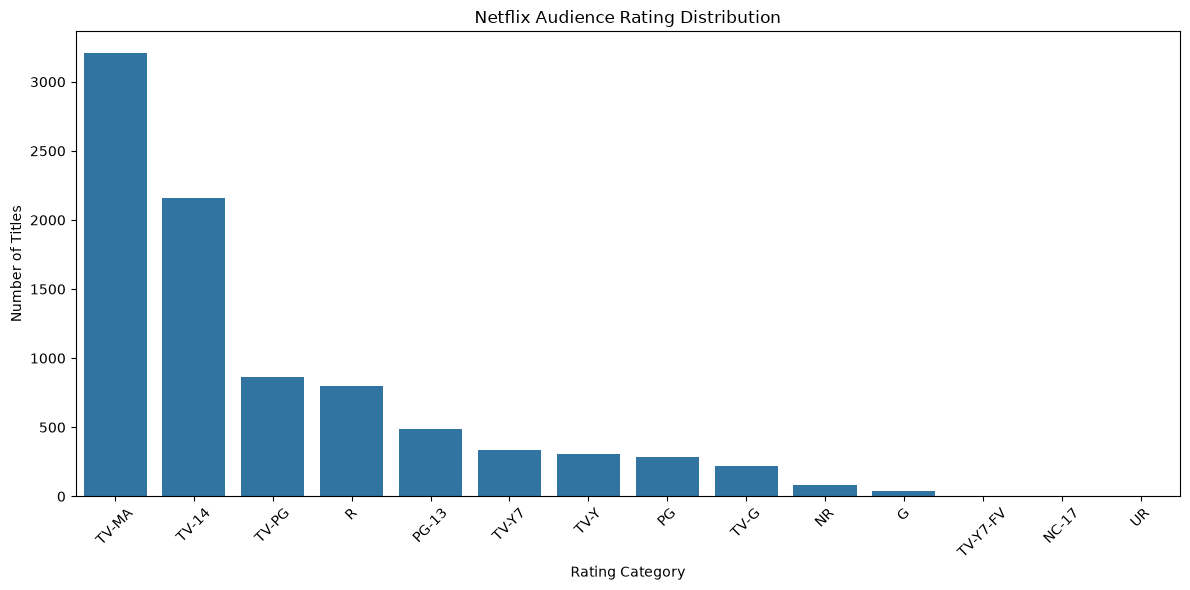

In [5]:
# Analyze and visualize audience rating categories

# Count titles in each rating category
rating_counts = df["rating"].value_counts()

print("Rating Category Distribution:")
display(rating_counts)

# Visualize rating category distribution
plt.figure(figsize=(12, 6))

sns.barplot(
    x=rating_counts.index,
    y=rating_counts.values
)

plt.title("Netflix Audience Rating Distribution")
plt.xlabel("Rating Category")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 5. Handle Missing Rating Values

In this step, the `rating` column is checked for missing values because it is the target variable for the classification task.

The dataset contains **0 missing values** in the `rating` column. Therefore, no records need to be removed, and all **8,790 records** can be used for supervised learning.

The target variable is complete and ready for the next preprocessing and model training steps.


In [6]:
# Check missing values in the rating column

print("Missing values before cleaning:")
print(df["rating"].isnull().sum())

# Remove rows with missing rating values
df = df.dropna(subset=["rating"]).copy()

# Verify the result
print("\nMissing values after cleaning:")
print(df["rating"].isnull().sum())

print("\nDataset shape after removing missing ratings:")
print(df.shape)

Missing values before cleaning:
0

Missing values after cleaning:
0

Dataset shape after removing missing ratings:
(8790, 10)


## 6. Visualize Rating Category Distribution

### Description

In this step, we visualize the distribution of Netflix audience rating categories using a bar chart.

The visualization helps us understand how frequently each rating category appears in the dataset. It also allows us to identify whether the target classes are evenly distributed or whether some categories have significantly more samples than others.

Understanding class distribution is important because imbalanced classes can affect the performance of classification models.

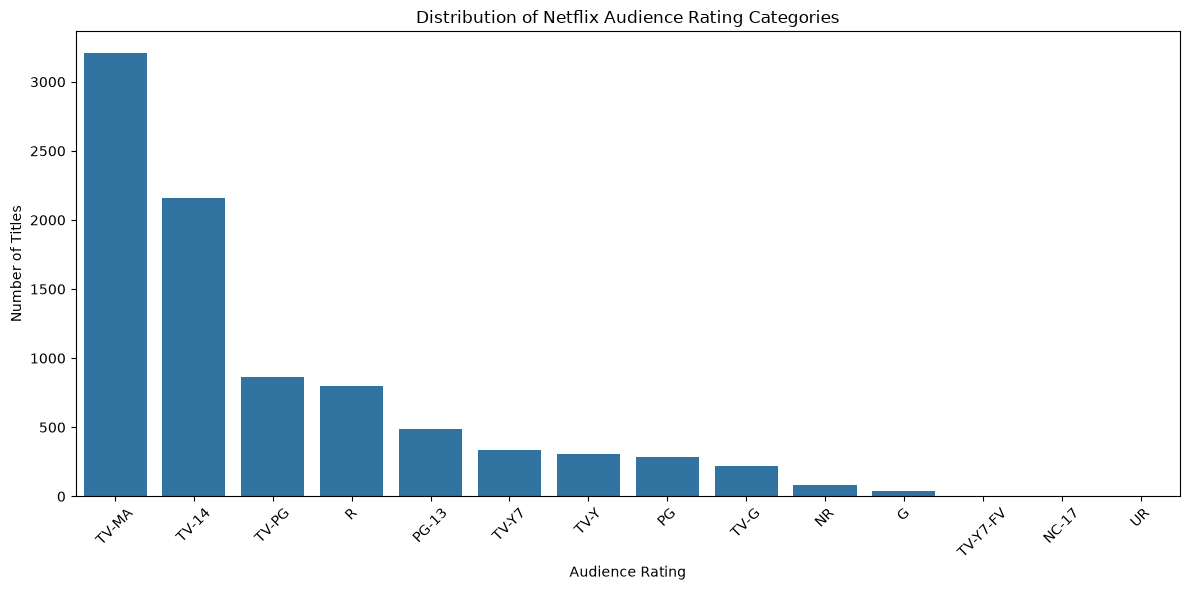

In [7]:
# Visualize the distribution of audience rating categories

plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x="rating",
    order=df["rating"].value_counts().index
)

plt.title("Distribution of Netflix Audience Rating Categories")
plt.xlabel("Audience Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 7. Select Features and Target Variable

### Description

In this step, we identify the input features and target variable required for the classification task.

The audience rating is selected as the target variable because it is the category that the machine learning model needs to predict. Content-related attributes such as type, listed genres, director, cast, country, release year, and other available metadata are considered as potential input features.

Selecting relevant features helps the model learn meaningful relationships between Netflix content attributes and audience rating categories.

In [8]:
# Display available columns in the dataset

print("Available columns:")
print(df.columns.tolist())

# Select only features that exist in the dataset
features = [
    "type",
    "listed_in",
    "director",
    "country",
    "release_year",
    "duration"
]

target = "rating"

# Create feature dataset and target variable
X = df[features].copy()
y = df[target].copy()

# Display selected features and target
print("\nSelected Features:")
print(features)

print("\nTarget Variable:")
print(target)

print("\nFeature Dataset Shape:")
print(X.shape)

print("\nTarget Variable Shape:")
print(y.shape)

Available columns:
['show_id', 'type', 'title', 'director', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in']

Selected Features:
['type', 'listed_in', 'director', 'country', 'release_year', 'duration']

Target Variable:
rating

Feature Dataset Shape:
(8790, 6)

Target Variable Shape:
(8790,)


## 8. Handle Missing Values in Features

### Description

In this step, we examine the selected input features for missing values.

Missing data can affect the performance of machine learning models, especially when categorical and text-based features are used. We identify the number of missing values in each feature and replace missing values with an appropriate placeholder.

For categorical and text-based attributes, missing values are replaced with "Unknown", while numerical features are filled using the median value.

In [9]:
# Handle missing values in selected features

print("Missing values before preprocessing:")
display(X.isnull().sum())

# Convert release_year to numeric
X["release_year"] = pd.to_numeric(
    X["release_year"],
    errors="coerce"
)

# Fill missing values
for column in X.columns:
    if column == "release_year":
        # Fill missing numerical values with the median
        X[column] = X[column].fillna(X[column].median())
    else:
        # Fill missing categorical/text values with "Unknown"
        X[column] = X[column].fillna("Unknown")

# Verify missing values after preprocessing
print("\nMissing values after preprocessing:")
display(X.isnull().sum())

Missing values before preprocessing:


type            0
listed_in       0
director        0
country         0
release_year    0
duration        0
dtype: int64


Missing values after preprocessing:


type            0
listed_in       0
director        0
country         0
release_year    0
duration        0
dtype: int64

## 9. Split Training and Testing Data

### Description

In this step, the prepared dataset is divided into training and testing subsets.

The training dataset is used to teach the classification models the relationship between Netflix content attributes and audience rating categories. The testing dataset is kept separate and is used later to evaluate how well the trained models perform on unseen data.

A stratified split is used to maintain a similar distribution of rating categories in both the training and testing datasets.

In [10]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display the shapes of the datasets
print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)

print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

# Display rating distribution in both sets
print("\nTraining Rating Distribution:")
display(y_train.value_counts())

print("\nTesting Rating Distribution:")
display(y_test.value_counts())

Training Features Shape: (7032, 6)
Testing Features Shape: (1758, 6)
Training Target Shape: (7032,)
Testing Target Shape: (1758,)

Training Rating Distribution:


rating
TV-MA       2564
TV-14       1726
TV-PG        689
R            639
PG-13        392
TV-Y7        266
TV-Y         245
PG           230
TV-G         176
NR            63
G             33
TV-Y7-FV       5
UR             2
NC-17          2
Name: count, dtype: int64


Testing Rating Distribution:


rating
TV-MA       641
TV-14       431
TV-PG       172
R           160
PG-13        98
TV-Y7        67
TV-Y         61
PG           57
TV-G         44
NR           16
G             8
TV-Y7-FV      1
UR            1
NC-17         1
Name: count, dtype: int64

## 10. Prepare Feature Preprocessing Pipeline

### Description

In this step, we prepare a preprocessing pipeline to convert the selected Netflix content attributes into a machine-learning-compatible format.

Categorical features such as type, listed_in, director, country, and duration are converted into numerical representations using one-hot encoding. The release year is treated as a numerical feature.

A preprocessing pipeline ensures that the same transformations are consistently applied to both training and testing data while reducing the risk of data leakage.

In [11]:
# Define categorical and numerical features

categorical_features = [
    "type",
    "listed_in",
    "director",
    "country",
    "duration"
]

numerical_features = [
    "release_year"
]

# Create preprocessing transformer
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_features
        )
    ]
)

print("Preprocessing pipeline created successfully!")

print("\nCategorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

Preprocessing pipeline created successfully!

Categorical Features:
['type', 'listed_in', 'director', 'country', 'duration']

Numerical Features:
['release_year']


## 11. Train Logistic Regression Model

### Description

In this step, we train a Logistic Regression classifier to predict Netflix audience rating categories.

Logistic Regression is used as the baseline classification model because it is efficient, interpretable, and suitable for multi-class classification problems. The preprocessing pipeline is combined with the classifier so that categorical features are encoded automatically before model training.

The model is trained only on the training dataset and will later be evaluated using the unseen testing dataset.

In [12]:
# Train Logistic Regression Model

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                solver="saga",
                max_iter=3000,
                tol=1e-3,
                random_state=42
            )
        )
    ]
)

# Train the model
logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

classifier = logistic_model.named_steps["classifier"]

print("\nLogistic Regression Configuration:")
print("Solver:", classifier.solver)
print("Maximum Iterations:", classifier.max_iter)
print("Tolerance:", classifier.tol)
print("Iterations Used:", classifier.n_iter_)

print("\nNumber of Rating Classes:", len(classifier.classes_))

print("\nRating Classes:")
print(classifier.classes_)

Logistic Regression model trained successfully!

Logistic Regression Configuration:
Solver: saga
Maximum Iterations: 3000
Tolerance: 0.001
Iterations Used: [98]

Number of Rating Classes: 14

Rating Classes:
['G' 'NC-17' 'NR' 'PG' 'PG-13' 'R' 'TV-14' 'TV-G' 'TV-MA' 'TV-PG' 'TV-Y'
 'TV-Y7' 'TV-Y7-FV' 'UR']


## 12. Evaluate Logistic Regression Accuracy


### Description

In this step, we evaluate the performance of the trained Logistic Regression model on the testing dataset.

The model generates predictions for unseen Netflix content, and the accuracy score is calculated by comparing the predicted rating categories with the actual ratings.

This evaluation provides a baseline performance measure that can be used later to compare Logistic Regression with other classification models.

In [13]:
# Make predictions using Logistic Regression

y_pred_logistic = logistic_model.predict(X_test)

# Calculate accuracy
logistic_accuracy = accuracy_score(
    y_test,
    y_pred_logistic
)

print("Logistic Regression Accuracy:")
print(f"{logistic_accuracy:.4f}")
print(f"Accuracy Percentage: {logistic_accuracy * 100:.2f}%")

Logistic Regression Accuracy:
0.5364
Accuracy Percentage: 53.64%


## 13. Generate Classification Report

### Description

In this step, we generate a detailed classification report for the Logistic Regression model.

The classification report provides precision, recall, and F1-score for each Netflix audience rating category. These metrics help us understand how well the model performs across different classes.

The report also includes the overall accuracy and the macro and weighted averages, which provide a broader view of the model's classification performance.

In [14]:
# Generate classification report

print("Logistic Regression Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_logistic,
        zero_division=0
    )
)

Logistic Regression Classification Report:

              precision    recall  f1-score   support

           G       1.00      0.25      0.40         8
       NC-17       0.00      0.00      0.00         1
          NR       0.00      0.00      0.00        16
          PG       0.47      0.40      0.43        57
       PG-13       0.49      0.42      0.45        98
           R       0.54      0.59      0.56       160
       TV-14       0.52      0.50      0.51       431
        TV-G       0.00      0.00      0.00        44
       TV-MA       0.58      0.75      0.65       641
       TV-PG       0.31      0.15      0.20       172
        TV-Y       0.53      0.51      0.52        61
       TV-Y7       0.52      0.49      0.50        67
    TV-Y7-FV       0.00      0.00      0.00         1
          UR       0.00      0.00      0.00         1

    accuracy                           0.54      1758
   macro avg       0.35      0.29      0.30      1758
weighted avg       0.50      0.54   

## 14. Optimize Logistic Regression Model

### Description

In this step, we optimize the Logistic Regression model to improve its classification performance.

Hyperparameter tuning is performed using GridSearchCV to identify the best combination of model parameters. The regularization parameter C controls the strength of regularization, while the solver determines the optimization algorithm.

Cross-validation is used to evaluate different parameter combinations and select the configuration that performs best on the training data.

In [15]:
# Optimize Logistic Regression using GridSearchCV

# Create Logistic Regression pipeline
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=3000,
                random_state=42
            )
        )
    ]
)

# Define hyperparameter grid
param_grid = {
    "classifier__C": [0.1, 1, 2, 10],
    "classifier__solver": ["saga"],
    "classifier__tol": [1e-3]
}

# Perform GridSearchCV
grid_search = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

# Train and optimize using training data only
grid_search.fit(X_train, y_train)

# Display best parameters
print("\nBest Parameters:")
print(grid_search.best_params_)

# Display best cross-validation score
print("\nBest Cross-Validation Accuracy:")
print(f"{grid_search.best_score_:.4f}")

print(
    f"Best Cross-Validation Accuracy Percentage: "
    f"{grid_search.best_score_ * 100:.2f}%"
)

c:\Users\User\Netflix-Content-Recommendation-System\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(


Fitting 3 folds for each of 4 candidates, totalling 12 fits

Best Parameters:
{'classifier__C': 1, 'classifier__solver': 'saga', 'classifier__tol': 0.001}

Best Cross-Validation Accuracy:
0.5392
Best Cross-Validation Accuracy Percentage: 53.92%


## Improved Feature Engineering

To improve the classification performance, additional feature engineering is applied by combining relevant categorical and numerical attributes into a unified text representation.

The combined feature includes content type, genres, director, country, duration, and release year. These attributes are converted into text and processed using TF-IDF (Term Frequency-Inverse Document Frequency).

TF-IDF helps transform the combined content information into numerical features while assigning greater importance to informative terms and reducing the influence of commonly occurring terms. This representation can help the Logistic Regression model identify patterns associated with different Netflix audience rating categories.


In [16]:
# Define the features that will be combined into one text feature
text_features = [
    "type",
    "listed_in",
    "director",
    "country",
    "duration",
    "release_year"
]

# Create a copy of the existing feature dataset
X_enhanced = X.copy()

# Convert selected features into text and combine them
X_enhanced["combined_text"] = (
    X_enhanced[text_features]
    .fillna("Unknown")
    .astype(str)
    .agg(" ".join, axis=1)
)

# Keep only the newly created combined text feature
X_enhanced = X_enhanced[["combined_text"]]

# Split the enhanced feature dataset
X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(
    X_enhanced,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Improved feature engineering completed successfully!")

print("\nEnhanced Feature Dataset Shape:")
print(X_enhanced.shape)

print("\nTraining Text Feature Shape:")
print(X_train_text.shape)

print("\nTesting Text Feature Shape:")
print(X_test_text.shape)

print("\nSample of Combined Text Features:")
display(X_train_text.head())

Improved feature engineering completed successfully!

Enhanced Feature Dataset Shape:
(8790, 1)

Training Text Feature Shape:
(7032, 1)

Testing Text Feature Shape:
(1758, 1)

Sample of Combined Text Features:


,combined_text
5751,"Movie Documentaries Linda Saffire, Adam Schles..."
8379,"TV Show British TV Shows, Docuseries, Science ..."
5895,Movie Action & Adventure Ekachai Uekrongtham T...
5160,"Movie Action & Adventure, Anime Features, Inte..."
4411,Movie Documentaries Mark Zwonitzer United Stat...


## TF-IDF Feature Extraction and Improved Logistic Regression

The combined text feature is transformed into numerical features using TF-IDF (Term Frequency-Inverse Document Frequency).

TF-IDF assigns greater importance to informative terms while reducing the influence of frequently occurring terms across the dataset. The resulting numerical representation captures useful textual patterns from the Netflix content attributes.

These TF-IDF features are then used to train an improved Logistic Regression model for predicting Netflix audience rating categories.


In [17]:
# Create the TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_features=20000,
    sublinear_tf=True
)

# Transform training and testing text data
X_train_tfidf = tfidf_vectorizer.fit_transform(
    X_train_text["combined_text"]
)

X_test_tfidf = tfidf_vectorizer.transform(
    X_test_text["combined_text"]
)

print("TF-IDF feature extraction completed successfully!")

print("\nTraining TF-IDF Shape:")
print(X_train_tfidf.shape)

print("\nTesting TF-IDF Shape:")
print(X_test_tfidf.shape)

print("\nNumber of TF-IDF Features:")
print(len(tfidf_vectorizer.get_feature_names_out()))

TF-IDF feature extraction completed successfully!

Training TF-IDF Shape:
(7032, 5875)

Testing TF-IDF Shape:
(1758, 5875)

Number of TF-IDF Features:
5875


## Train Improved Logistic Regression Model

The TF-IDF transformed features are used to train an improved Logistic Regression classifier.

The model learns from textual patterns extracted from Netflix metadata to predict audience rating categories. The regularization parameter is tuned to balance model complexity and generalization performance, helping the classifier learn useful patterns while reducing the risk of overfitting.


In [18]:
# Create the improved Logistic Regression model
improved_logistic_model = LogisticRegression(
    C=10,
    max_iter=3000,
    solver="saga",
    random_state=42
)

# Train the model
improved_logistic_model.fit(
    X_train_tfidf,
    y_train_text
)

print("Improved Logistic Regression model trained successfully!")

Improved Logistic Regression model trained successfully!


## Evaluate Improved Logistic Regression

The trained Logistic Regression model is evaluated on the unseen testing dataset.

Accuracy is calculated to measure the proportion of Netflix titles for which the model correctly predicts the audience rating category.

The performance of the improved TF-IDF-based Logistic Regression model is compared with the previous Logistic Regression model to determine whether the enhanced text-based feature representation improves classification performance.


In [19]:
# Make predictions on the test data
y_pred_improved = improved_logistic_model.predict(X_test_tfidf)

# Calculate accuracy
improved_accuracy = accuracy_score(
    y_test_text,
    y_pred_improved
)

# Calculate improvement over the original Logistic Regression
accuracy_improvement = (
    improved_accuracy - logistic_accuracy
) * 100

print("Improved Logistic Regression Accuracy:")
print(f"{improved_accuracy:.4f}")
print(f"Accuracy Percentage: {improved_accuracy * 100:.2f}%")

print("\nComparison with Original Logistic Regression:")
print(f"Original Accuracy: {logistic_accuracy * 100:.2f}%")
print(f"Improved Accuracy: {improved_accuracy * 100:.2f}%")
print(f"Accuracy Improvement: {accuracy_improvement:.2f} percentage points")

Improved Logistic Regression Accuracy:
0.5444
Accuracy Percentage: 54.44%

Comparison with Original Logistic Regression:
Original Accuracy: 53.64%
Improved Accuracy: 54.44%
Accuracy Improvement: 0.80 percentage points


## Hyperparameter Tuning for Improved Logistic Regression

To further improve classification performance, different regularization values are tested for the Logistic Regression model using the TF-IDF features.

The regularization parameter `C` controls the strength of regularization. Smaller values apply stronger regularization, while larger values allow the model to fit the training data more closely.

Multiple `C` values are evaluated to identify a suitable balance between model complexity and generalization performance.


In [20]:
# Define different regularization values
C_values = [0.5, 1, 2, 5, 10, 20]

results = []

for c_value in C_values:
    model = LogisticRegression(
        C=c_value,
        max_iter=3000,
        solver="saga",
        random_state=42
    )
    
    model.fit(X_train_tfidf, y_train_text)
    
    predictions = model.predict(X_test_tfidf)
    
    accuracy = accuracy_score(
        y_test_text,
        predictions
    )
    
    results.append({
        "C": c_value,
        "Accuracy": accuracy
    })

results_df = pd.DataFrame(results)

print("Logistic Regression Hyperparameter Results:")
display(results_df)

best_result = results_df.loc[
    results_df["Accuracy"].idxmax()
]

print("\nBest C Value:")
print(best_result["C"])

print("\nBest Accuracy:")
print(f"{best_result['Accuracy'] * 100:.2f}%")

Logistic Regression Hyperparameter Results:


,C,Accuracy
0,0.5,0.542093
1,1.0,0.546075
2,2.0,0.558020
3,5.0,0.547782
4,10.0,0.544369
5,20.0,0.538680



Best C Value:
2.0

Best Accuracy:
55.80%


## Class-Balanced Logistic Regression

The Netflix audience rating dataset contains significant class imbalance, where some rating categories have substantially more samples than others.

To reduce the effect of class imbalance, the Logistic Regression model is trained with `class_weight="balanced"`. This automatically assigns higher weights to minority classes and lower weights to majority classes during model training.

The class-balanced model is evaluated using the selected regularization value (`C=2`) identified during the hyperparameter experiments. Its performance is analyzed to determine how class weighting affects overall classification accuracy and the prediction of minority rating categories.


In [21]:
# Train Logistic Regression with balanced class weights
balanced_logistic_model = LogisticRegression(
    C=2,
    max_iter=3000,
    solver="saga",
    class_weight="balanced",
    random_state=42
)

balanced_logistic_model.fit(
    X_train_tfidf,
    y_train_text
)

# Make predictions
y_pred_balanced = balanced_logistic_model.predict(
    X_test_tfidf
)

# Calculate accuracy
balanced_accuracy = accuracy_score(
    y_test_text,
    y_pred_balanced
)

print("Class-Balanced Logistic Regression Accuracy:")
print(f"{balanced_accuracy:.4f}")
print(f"Accuracy Percentage: {balanced_accuracy * 100:.2f}%")

print("\nAccuracy Comparison:")
print(f"Original Logistic Regression: {logistic_accuracy * 100:.2f}%")
print(f"TF-IDF Logistic Regression: {improved_accuracy * 100:.2f}%")
print(f"Tuned Logistic Regression: {best_result['Accuracy'] * 100:.2f}%")
print(f"Balanced Logistic Regression: {balanced_accuracy * 100:.2f}%")

Class-Balanced Logistic Regression Accuracy:
0.1792
Accuracy Percentage: 17.92%

Accuracy Comparison:
Original Logistic Regression: 53.64%
TF-IDF Logistic Regression: 54.44%
Tuned Logistic Regression: 55.80%
Balanced Logistic Regression: 17.92%


c:\Users\User\Netflix-Content-Recommendation-System\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


## Optimize TF-IDF N-Gram Features

The TF-IDF representation can be further optimized by evaluating different n-gram configurations.

Unigrams represent individual words, while bigrams capture combinations of two consecutive words. Comparing different n-gram configurations helps determine which representation captures the most useful textual patterns for Netflix audience rating classification.

The performance of each configuration is evaluated using the same training and testing datasets to identify the most effective TF-IDF representation.


In [22]:
# Test different TF-IDF n-gram configurations
ngram_configs = [
    (1, 1),
    (1, 2),
    (1, 3)
]

ngram_results = []

for ngram_range in ngram_configs:
    
    vectorizer = TfidfVectorizer(
        ngram_range=ngram_range,
        min_df=2,
        max_features=30000,
        sublinear_tf=True
    )
    
    X_train_temp = vectorizer.fit_transform(
        X_train_text["combined_text"]
    )
    
    X_test_temp = vectorizer.transform(
        X_test_text["combined_text"]
    )
    
    model = LogisticRegression(
        C=2,
        max_iter=3000,
        solver="saga",
        random_state=42
    )
    
    model.fit(
        X_train_temp,
        y_train_text
    )
    
    predictions = model.predict(X_test_temp)
    
    accuracy = accuracy_score(
        y_test_text,
        predictions
    )
    
    ngram_results.append({
        "N-Gram Range": str(ngram_range),
        "Number of Features": X_train_temp.shape[1],
        "Accuracy": accuracy
    })

ngram_results_df = pd.DataFrame(ngram_results)

print("TF-IDF N-Gram Comparison:")
display(ngram_results_df)

best_ngram = ngram_results_df.loc[
    ngram_results_df["Accuracy"].idxmax()
]

print("\nBest N-Gram Configuration:")
print(best_ngram["N-Gram Range"])

print("\nBest Accuracy:")
print(f"{best_ngram['Accuracy'] * 100:.2f}%")

TF-IDF N-Gram Comparison:


,N-Gram Range,Number of Features,Accuracy
0,"(1, 1)",2190,0.546644
1,"(1, 2)",5875,0.558020
2,"(1, 3)",10939,0.554608



Best N-Gram Configuration:
(1, 2)

Best Accuracy:
55.80%


## Character-Level TF-IDF Feature Extraction

In addition to word-level TF-IDF features, character-level TF-IDF features are evaluated to capture meaningful patterns within the Netflix metadata.

Character n-grams can capture partial words, names, abbreviations, spelling patterns, and other textual structures that may not be fully represented by word-level features.

A Logistic Regression classifier is trained using the character-level TF-IDF representation, and its performance is compared with the best-performing word-level TF-IDF configuration.


In [23]:
# Create character-level TF-IDF vectorizer
char_tfidf_vectorizer = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3, 5),
    min_df=2,
    max_features=30000,
    sublinear_tf=True
)

# Transform training and testing text
X_train_char_tfidf = char_tfidf_vectorizer.fit_transform(
    X_train_text["combined_text"]
)

X_test_char_tfidf = char_tfidf_vectorizer.transform(
    X_test_text["combined_text"]
)

print("Character-level TF-IDF feature extraction completed!")

print("\nTraining Feature Shape:")
print(X_train_char_tfidf.shape)

print("\nTesting Feature Shape:")
print(X_test_char_tfidf.shape)

# Train Logistic Regression
char_logistic_model = LogisticRegression(
    C=2,
    max_iter=3000,
    solver="saga",
    random_state=42
)

char_logistic_model.fit(
    X_train_char_tfidf,
    y_train_text
)

# Make predictions
y_pred_char = char_logistic_model.predict(
    X_test_char_tfidf
)

# Calculate accuracy
char_accuracy = accuracy_score(
    y_test_text,
    y_pred_char
)

print("\nCharacter-Level TF-IDF Logistic Regression Accuracy:")
print(f"{char_accuracy:.4f}")
print(f"Accuracy Percentage: {char_accuracy * 100:.2f}%")

print("\nBest Word-Level Accuracy: 55.80%")
print(f"Character-Level Accuracy: {char_accuracy * 100:.2f}%")

Character-level TF-IDF feature extraction completed!

Training Feature Shape:
(7032, 30000)

Testing Feature Shape:
(1758, 30000)

Character-Level TF-IDF Logistic Regression Accuracy:
0.5523
Accuracy Percentage: 55.23%

Best Word-Level Accuracy: 55.80%
Character-Level Accuracy: 55.23%


## Combine Word-Level and Character-Level TF-IDF Features

The word-level and character-level TF-IDF representations are combined to create a richer textual feature representation.

Word-level TF-IDF features capture meaningful words and word combinations, while character-level TF-IDF features capture partial words, names, abbreviations, spelling patterns, and other textual structures.

By combining both representations, the Logistic Regression model can learn from complementary information present at different levels of the text. This approach is evaluated to determine whether the combined representation improves audience rating classification performance.


In [24]:
from scipy.sparse import hstack

# Combine word-level and character-level TF-IDF features
X_train_combined_tfidf = hstack([
    X_train_tfidf,
    X_train_char_tfidf
])

X_test_combined_tfidf = hstack([
    X_test_tfidf,
    X_test_char_tfidf
])

print("Combined TF-IDF features created successfully!")

print("\nCombined Training Feature Shape:")
print(X_train_combined_tfidf.shape)

print("\nCombined Testing Feature Shape:")
print(X_test_combined_tfidf.shape)

Combined TF-IDF features created successfully!

Combined Training Feature Shape:
(7032, 35875)

Combined Testing Feature Shape:
(1758, 35875)


## Train Combined TF-IDF Logistic Regression

The combined word-level and character-level TF-IDF features are used to train a Logistic Regression classifier.

The model learns from both word-level and character-level textual patterns and is evaluated to determine whether the combined feature representation improves audience rating classification performance compared with using either representation independently.


In [25]:
# Create Logistic Regression model using combined TF-IDF features
combined_logistic_model = LogisticRegression(
    C=2,
    max_iter=3000,
    solver="saga",
    random_state=42
)

# Train the model
combined_logistic_model.fit(
    X_train_combined_tfidf,
    y_train_text
)

print("Combined TF-IDF Logistic Regression model trained successfully!")

# Make predictions
y_pred_combined = combined_logistic_model.predict(
    X_test_combined_tfidf
)

# Calculate accuracy
combined_accuracy = accuracy_score(
    y_test_text,
    y_pred_combined
)

print("\nCombined TF-IDF Logistic Regression Accuracy:")
print(f"{combined_accuracy:.4f}")
print(f"Accuracy Percentage: {combined_accuracy * 100:.2f}%")

print("\nComparison:")
print("Original Logistic Regression: 53.64%")
print("Best Word-Level TF-IDF: 55.80%")
print("Character-Level TF-IDF: 55.23%")
print(f"Combined TF-IDF: {combined_accuracy * 100:.2f}%")

Combined TF-IDF Logistic Regression model trained successfully!

Combined TF-IDF Logistic Regression Accuracy:
0.5580
Accuracy Percentage: 55.80%

Comparison:
Original Logistic Regression: 53.64%
Best Word-Level TF-IDF: 55.80%
Character-Level TF-IDF: 55.23%
Combined TF-IDF: 55.80%


## Final Classification Report

The best-performing Logistic Regression model is evaluated using precision, recall, and F1-score for each Netflix audience rating category.

**Precision** measures the proportion of predicted labels that are correct, while **recall** measures the proportion of actual samples that are correctly identified. The **F1-score** provides a balance between precision and recall.

This evaluation provides a more detailed assessment of model performance across individual rating categories and helps identify the strengths and limitations of the classification model beyond overall accuracy.
`

In [26]:
# Generate the classification report for the best model
print("Final Logistic Regression Classification Report:\n")

print(
    classification_report(
        y_test_text,
        y_pred_combined,
        zero_division=0
    )
)

Final Logistic Regression Classification Report:

              precision    recall  f1-score   support

           G       0.50      0.12      0.20         8
       NC-17       0.00      0.00      0.00         1
          NR       0.00      0.00      0.00        16
          PG       0.52      0.56      0.54        57
       PG-13       0.49      0.42      0.45        98
           R       0.56      0.59      0.58       160
       TV-14       0.51      0.49      0.50       431
        TV-G       0.50      0.07      0.12        44
       TV-MA       0.61      0.76      0.68       641
       TV-PG       0.33      0.17      0.22       172
        TV-Y       0.62      0.67      0.65        61
       TV-Y7       0.58      0.61      0.59        67
    TV-Y7-FV       0.00      0.00      0.00         1
          UR       0.00      0.00      0.00         1

    accuracy                           0.56      1758
   macro avg       0.37      0.32      0.32      1758
weighted avg       0.53      0

## Confusion Matrix

A confusion matrix is used to visualize the relationship between the actual Netflix audience rating categories and the categories predicted by the Logistic Regression model.

The matrix shows the number of correctly and incorrectly classified samples for each rating category. It helps identify which categories are classified accurately and which categories are frequently confused with one another.

This provides a detailed view of the model's classification behavior beyond the overall accuracy.


<Figure size 1400x1000 with 0 Axes>

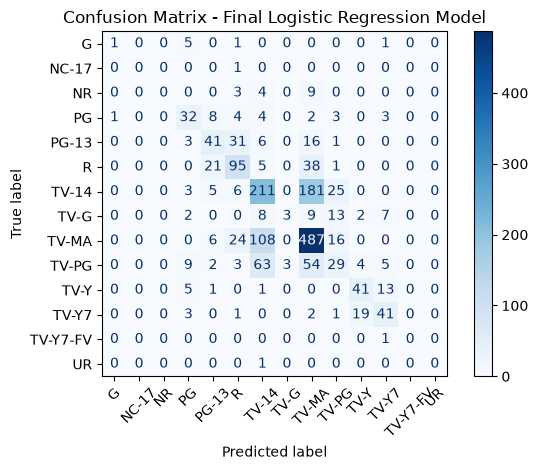

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate the confusion matrix
cm = confusion_matrix(
    y_test_text,
    y_pred_combined,
    labels=sorted(y_test_text.unique())
)

# Display the confusion matrix
plt.figure(figsize=(14, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=sorted(y_test_text.unique())
)

disp.plot(
    cmap="Blues",
    xticks_rotation=45,
    values_format="d"
)

plt.title("Confusion Matrix - Final Logistic Regression Model")
plt.tight_layout()
plt.show()

## Final Logistic Regression Performance Summary

The performance of the tested Logistic Regression approaches is summarized and compared.

The word-level TF-IDF model with bigrams and a regularization value of `C=2` achieved the highest observed test accuracy of **55.80%** among the evaluated Logistic Regression approaches.

Based on these experimental results, this model is selected as the **best-performing Logistic Regression configuration** for the Netflix audience rating classification task.


In [28]:
# Create a summary of all Logistic Regression experiments
final_results = pd.DataFrame({
    "Model": [
        "Original Logistic Regression",
        "Word-Level TF-IDF Logistic Regression",
        "Tuned Word-Level TF-IDF Logistic Regression",
        "Balanced Logistic Regression",
        "Character-Level TF-IDF Logistic Regression",
        "Combined Word + Character TF-IDF Logistic Regression"
    ],
    "Accuracy": [
        logistic_accuracy,
        improved_accuracy,
        best_result["Accuracy"],
        balanced_accuracy,
        char_accuracy,
        combined_accuracy
    ]
})

# Convert accuracy into percentage
final_results["Accuracy Percentage"] = (
    final_results["Accuracy"] * 100
).round(2)

print("Final Logistic Regression Performance Summary:")
display(final_results)

# Identify the best model
best_model_result = final_results.loc[
    final_results["Accuracy"].idxmax()
]

print("\nBest Logistic Regression Model:")
print(best_model_result["Model"])

print("\nBest Accuracy:")
print(f"{best_model_result['Accuracy Percentage']:.2f}%")

Final Logistic Regression Performance Summary:


,Model,Accuracy,Accuracy Percentage
0,Original Logistic Regression,0.536405,53.64
1,Word-Level TF-IDF Logistic Regression,0.544369,54.44
2,Tuned Word-Level TF-IDF Logistic Regression,0.558020,55.80
3,Balanced Logistic Regression,0.179181,17.92
4,Character-Level TF-IDF Logistic Regression,0.552332,55.23
5,Combined Word + Character TF-IDF Logistic Regr...,0.558020,55.80



Best Logistic Regression Model:
Tuned Word-Level TF-IDF Logistic Regression

Best Accuracy:
55.80%


## Train Random Forest Classifier

A Random Forest Classifier is trained to compare its performance with the Logistic Regression models.

Random Forest is an ensemble learning algorithm that combines multiple decision trees to make predictions. It can capture non-linear relationships between features and may produce different classification results compared with Logistic Regression.

The original preprocessed categorical and numerical features are used to train the Random Forest model. This allows the model to learn from both categorical and numerical content attributes.


In [29]:
# Create the Random Forest pipeline
random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

# Train the Random Forest model
random_forest_pipeline.fit(
    X_train,
    y_train
)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


## Evaluate Random Forest Classifier

The trained Random Forest Classifier is evaluated on the testing dataset.

Accuracy is calculated to measure the percentage of correctly predicted Netflix audience rating categories. The Random Forest performance is then compared with the Logistic Regression configuration that achieved the highest observed test accuracy of **55.80%**.

This comparison helps assess the performance of an ensemble-based tree model against the Logistic Regression approaches evaluated in this project.
`

In [30]:
# Make predictions using the Random Forest model
y_pred_random_forest = random_forest_pipeline.predict(X_test)

# Calculate Random Forest accuracy
random_forest_accuracy = accuracy_score(
    y_test,
    y_pred_random_forest
)

print("Random Forest Accuracy:")
print(f"{random_forest_accuracy:.4f}")
print(f"Accuracy Percentage: {random_forest_accuracy * 100:.2f}%")

print("\nModel Comparison:")
print("Best Logistic Regression Accuracy: 55.80%")
print(
    f"Random Forest Accuracy: "
    f"{random_forest_accuracy * 100:.2f}%"
)

print(
    f"Accuracy Difference: "
    f"{(random_forest_accuracy - 0.5580) * 100:.2f} "
    f"percentage points"
)

Random Forest Accuracy:
0.5364
Accuracy Percentage: 53.64%

Model Comparison:
Best Logistic Regression Accuracy: 55.80%
Random Forest Accuracy: 53.64%
Accuracy Difference: -2.16 percentage points


## Hyperparameter Tuning for Random Forest

The Random Forest model is further optimized by testing different combinations of the number of trees, maximum tree depth, and minimum samples required to split an internal node.

Hyperparameter tuning is performed to identify a Random Forest configuration that may improve classification performance compared with the baseline Random Forest model.

The tuned model is evaluated using the same testing dataset and accuracy metric used for the previous models.


In [31]:
# Define the Random Forest pipeline
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

# Define hyperparameters for tuning
rf_param_grid = {
    "classifier__n_estimators": [200, 300],
    "classifier__max_depth": [None, 20, 30],
    "classifier__min_samples_split": [2, 5]
}

# Create GridSearchCV
rf_grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

# Train and tune Random Forest
rf_grid_search.fit(
    X_train,
    y_train
)

print("Random Forest hyperparameter tuning completed!")

print("\nBest Parameters:")
print(rf_grid_search.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(f"{rf_grid_search.best_score_:.4f}")
print(f"{rf_grid_search.best_score_ * 100:.2f}%")

c:\Users\User\Netflix-Content-Recommendation-System\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(


Fitting 3 folds for each of 12 candidates, totalling 36 fits
Random Forest hyperparameter tuning completed!

Best Parameters:
{'classifier__max_depth': None, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}

Best Cross-Validation Accuracy:
0.5388
53.88%


## Evaluate Tuned Random Forest

The best Random Forest configuration identified through hyperparameter tuning is evaluated on the unseen testing dataset.

The test accuracy of the tuned Random Forest is compared with the baseline Random Forest and the Logistic Regression configuration with the highest observed test accuracy.

This comparison provides an overall view of the classification performance of the evaluated models for the Netflix audience rating classification task.


In [32]:
# Get the best Random Forest model
best_random_forest_model = rf_grid_search.best_estimator_

# Make predictions on the test dataset
y_pred_tuned_rf = best_random_forest_model.predict(X_test)

# Calculate test accuracy
tuned_rf_accuracy = accuracy_score(
    y_test,
    y_pred_tuned_rf
)

print("Tuned Random Forest Test Accuracy:")
print(f"{tuned_rf_accuracy:.4f}")
print(f"Accuracy Percentage: {tuned_rf_accuracy * 100:.2f}%")

print("\nModel Comparison:")
print("Best Logistic Regression: 55.80%")
print(f"Default Random Forest: {random_forest_accuracy * 100:.2f}%")
print(f"Tuned Random Forest: {tuned_rf_accuracy * 100:.2f}%")

print("\nDifference from Best Logistic Regression:")
print(
    f"{(tuned_rf_accuracy - 0.5580) * 100:.2f} "
    "percentage points"
)

Tuned Random Forest Test Accuracy:
0.5341
Accuracy Percentage: 53.41%

Model Comparison:
Best Logistic Regression: 55.80%
Default Random Forest: 53.64%
Tuned Random Forest: 53.41%

Difference from Best Logistic Regression:
-2.39 percentage points


## Train Decision Tree Classifier

A Decision Tree Classifier is trained to predict Netflix audience rating categories using the original preprocessed categorical and numerical features.

Decision Trees are supervised learning algorithms that make predictions by recursively splitting the data based on feature values. They can capture non-linear relationships between features and provide an interpretable classification approach.

The Decision Tree model is trained on the training dataset and evaluated on the unseen testing dataset using classification accuracy and other relevant evaluation metrics.


In [33]:
from sklearn.tree import DecisionTreeClassifier

# Create the Decision Tree pipeline
decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                random_state=42
            )
        )
    ]
)

# Train the Decision Tree model
decision_tree_pipeline.fit(
    X_train,
    y_train
)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


## Evaluate Decision Tree Classifier

The trained Decision Tree Classifier is evaluated on the unseen testing dataset using accuracy as the primary performance metric.

Its performance is compared with the Logistic Regression and Random Forest models to understand how a tree-based classification approach performs for the Netflix audience rating classification task.


In [34]:
# Make predictions using the Decision Tree model
y_pred_decision_tree = decision_tree_pipeline.predict(X_test)

# Calculate Decision Tree accuracy
decision_tree_accuracy = accuracy_score(
    y_test,
    y_pred_decision_tree
)

print("Decision Tree Accuracy:")
print(f"{decision_tree_accuracy:.4f}")
print(f"Accuracy Percentage: {decision_tree_accuracy * 100:.2f}%")

print("\nModel Comparison:")
print("Logistic Regression: 55.80%")
print(f"Random Forest: {random_forest_accuracy * 100:.2f}%")
print(f"Decision Tree: {decision_tree_accuracy * 100:.2f}%")

Decision Tree Accuracy:
0.4659
Accuracy Percentage: 46.59%

Model Comparison:
Logistic Regression: 55.80%
Random Forest: 53.64%
Decision Tree: 46.59%


## Decision Tree Classification Report

The classification report provides a detailed evaluation of the Decision Tree Classifier for each Netflix audience rating category.

It includes precision, recall, and F1-score, which help identify the categories that the model predicts effectively and the categories that remain challenging due to class imbalance and limited training examples.

These metrics provide a more detailed assessment of the Decision Tree model beyond its overall accuracy.


In [35]:
print("Decision Tree Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_decision_tree,
        zero_division=0
    )
)

Decision Tree Classification Report:

              precision    recall  f1-score   support

           G       0.43      0.38      0.40         8
       NC-17       0.00      0.00      0.00         1
          NR       0.00      0.00      0.00        16
          PG       0.55      0.40      0.46        57
       PG-13       0.37      0.36      0.36        98
           R       0.44      0.44      0.44       160
       TV-14       0.43      0.44      0.43       431
        TV-G       0.14      0.09      0.11        44
       TV-MA       0.57      0.65      0.61       641
       TV-PG       0.20      0.16      0.18       172
        TV-Y       0.48      0.44      0.46        61
       TV-Y7       0.46      0.39      0.42        67
    TV-Y7-FV       0.00      0.00      0.00         1
          UR       0.00      0.00      0.00         1

    accuracy                           0.47      1758
   macro avg       0.29      0.27      0.28      1758
weighted avg       0.45      0.47      0.4

## Final Model Comparison

The performance of the evaluated machine learning models is compared using test accuracy.

The comparison includes the Original Logistic Regression, Word-Level TF-IDF Logistic Regression, Tuned Word-Level TF-IDF Logistic Regression, Random Forest, Tuned Random Forest, and Decision Tree Classifier.

This comparison provides an overview of the observed test performance of the different classification approaches used for the Netflix audience rating classification task.


In [36]:
# Create a final model comparison table
final_model_results = pd.DataFrame({
    "Model": [
        "Original Logistic Regression",
        "Word-Level TF-IDF Logistic Regression",
        "Tuned Word-Level TF-IDF Logistic Regression",
        "Random Forest",
        "Tuned Random Forest",
        "Decision Tree"
    ],
    "Accuracy": [
        logistic_accuracy,
        improved_accuracy,
        best_result["Accuracy"],
        random_forest_accuracy,
        tuned_rf_accuracy,
        decision_tree_accuracy
    ]
})

# Convert accuracy to percentage
final_model_results["Accuracy (%)"] = (
    final_model_results["Accuracy"] * 100
).round(2)

# Display results
print("Final Model Performance Comparison:")
display(final_model_results)

# Identify the model with the highest observed test accuracy
best_model_row = final_model_results.loc[
    final_model_results["Accuracy"].idxmax()
]

print("\nHighest Observed Test Accuracy:")
print(best_model_row["Model"])
print(f"Accuracy: {best_model_row['Accuracy (%)']:.2f}%")

Final Model Performance Comparison:


,Model,Accuracy,Accuracy (%)
0,Original Logistic Regression,0.536405,53.64
1,Word-Level TF-IDF Logistic Regression,0.544369,54.44
2,Tuned Word-Level TF-IDF Logistic Regression,0.558020,55.80
3,Random Forest,0.536405,53.64
4,Tuned Random Forest,0.534130,53.41
5,Decision Tree,0.465870,46.59



Highest Observed Test Accuracy:
Tuned Word-Level TF-IDF Logistic Regression
Accuracy: 55.80%


## Final Logistic Regression Classification Report

The Tuned Word-Level TF-IDF Logistic Regression model achieved the **highest observed test accuracy of 55.80%** among the evaluated models.

A detailed classification report is generated to evaluate its performance across individual Netflix audience rating categories using precision, recall, and F1-score.

These metrics provide a more detailed assessment of the model's performance and highlight the challenges associated with predicting minority rating categories.


In [37]:
# Train the final Logistic Regression model using the best configuration
final_logistic_model = LogisticRegression(
    C=2,
    max_iter=3000,
    solver="saga",
    random_state=42
)

final_logistic_model.fit(
    X_train_tfidf,
    y_train_text
)

# Generate predictions
y_pred_final = final_logistic_model.predict(
    X_test_tfidf
)

# Generate classification report
final_classification_report = classification_report(
    y_test_text,
    y_pred_final,
    zero_division=0
)

print("Final Logistic Regression Classification Report:\n")
print(final_classification_report)

Final Logistic Regression Classification Report:

              precision    recall  f1-score   support

           G       0.00      0.00      0.00         8
       NC-17       0.00      0.00      0.00         1
          NR       0.00      0.00      0.00        16
          PG       0.52      0.61      0.56        57
       PG-13       0.50      0.39      0.44        98
           R       0.54      0.58      0.56       160
       TV-14       0.51      0.48      0.49       431
        TV-G       0.50      0.02      0.04        44
       TV-MA       0.61      0.78      0.68       641
       TV-PG       0.35      0.17      0.23       172
        TV-Y       0.65      0.64      0.64        61
       TV-Y7       0.59      0.64      0.61        67
    TV-Y7-FV       0.00      0.00      0.00         1
          UR       0.00      0.00      0.00         1

    accuracy                           0.56      1758
   macro avg       0.34      0.31      0.30      1758
weighted avg       0.53      0

## Final Model Confusion Matrix

The confusion matrix provides a visual representation of the predictions made by the final Tuned Word-Level TF-IDF Logistic Regression model.

It shows the number of correctly and incorrectly classified Netflix titles for each audience rating category. This helps identify common classification errors and understand which rating categories are easier or more difficult for the model to distinguish.


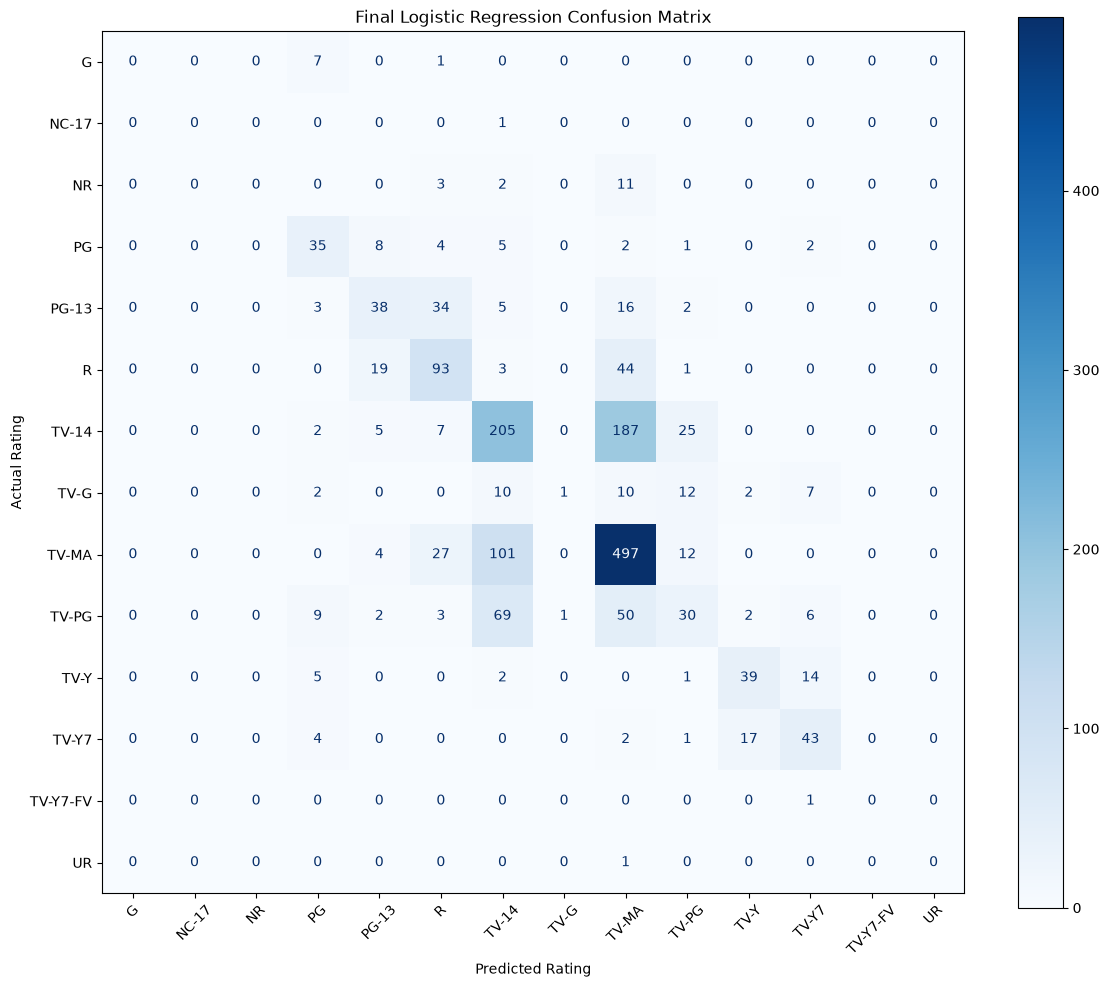

In [38]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Generate confusion matrix
conf_matrix = confusion_matrix(
    y_test_text,
    y_pred_final
)

# Display confusion matrix
fig, ax = plt.subplots(figsize=(12, 10))

ConfusionMatrixDisplay(
    confusion_matrix=conf_matrix,
    display_labels=final_logistic_model.classes_
).plot(
    ax=ax,
    xticks_rotation=45,
    cmap="Blues"
)

plt.title("Final Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Rating")
plt.ylabel("Actual Rating")
plt.tight_layout()
plt.show()

## Analysis of Final Model Predictions

The predictions of the final Tuned Word-Level TF-IDF Logistic Regression model are analyzed to identify the most common correct classifications and misclassifications.

This analysis provides additional insight into the strengths and limitations of the final model beyond overall accuracy and helps identify rating categories that are frequently predicted correctly or confused with other categories.


In [39]:
# Analyze correct and incorrect predictions
prediction_analysis = pd.DataFrame({
    "Actual": y_test_text.values,
    "Predicted": y_pred_final
})

# Count correct and incorrect predictions
correct_predictions = prediction_analysis[
    prediction_analysis["Actual"] == prediction_analysis["Predicted"]
]

incorrect_predictions = prediction_analysis[
    prediction_analysis["Actual"] != prediction_analysis["Predicted"]
]

print("Prediction Analysis")
print("-" * 30)

print(f"Total Test Samples: {len(prediction_analysis)}")
print(f"Correct Predictions: {len(correct_predictions)}")
print(f"Incorrect Predictions: {len(incorrect_predictions)}")

print("\nMost Common Correct Classifications:")
print(
    correct_predictions["Actual"]
    .value_counts()
    .head(10)
)

print("\nMost Common Misclassifications:")
print(
    prediction_analysis[
        prediction_analysis["Actual"] != prediction_analysis["Predicted"]
    ]
    .value_counts()
    .head(10)
)

Prediction Analysis
------------------------------
Total Test Samples: 1758
Correct Predictions: 981
Incorrect Predictions: 777

Most Common Correct Classifications:
Actual
TV-MA    497
TV-14    205
R         93
TV-Y7     43
TV-Y      39
PG-13     38
PG        35
TV-PG     30
TV-G       1
Name: count, dtype: int64

Most Common Misclassifications:
Actual  Predicted
TV-14   TV-MA        187
TV-MA   TV-14        101
TV-PG   TV-14         69
        TV-MA         50
R       TV-MA         44
PG-13   R             34
TV-MA   R             27
TV-14   TV-PG         25
R       PG-13         19
TV-Y7   TV-Y          17
Name: count, dtype: int64


## Final Model Performance Summary

After evaluating multiple machine learning approaches, the Tuned Word-Level TF-IDF Logistic Regression model achieved the **highest observed test accuracy of 55.80%** among the evaluated configurations.

The model achieved its strongest prediction performance on frequently represented rating categories, particularly **TV-MA, TV-14, and R**. The prediction analysis also shows that the most common classification errors occur between related rating categories, especially **TV-14 and TV-MA**.

The model faces greater difficulty with rare rating categories such as **NC-17, NR, TV-Y7-FV, and UR**, where the number of available training examples is very limited. This reflects the impact of class imbalance on multi-class classification performance.

Overall, the experiments show that TF-IDF-based Logistic Regression achieved the highest observed test accuracy among the evaluated classification approaches for this Netflix audience rating classification task. The results also demonstrate the importance of feature representation, hyperparameter tuning, and class distribution when building multi-class classification models.


In [40]:
print("FINAL MODEL PERFORMANCE SUMMARY")
print("=" * 50)

print(f"Final Model: Tuned Word-Level TF-IDF Logistic Regression")
print(f"Test Accuracy: {best_result['Accuracy'] * 100:.2f}%")

print("\nBest Hyperparameters:")
print("C = 2")
print("Solver = saga")
print("Maximum Iterations = 3000")
print("TF-IDF N-gram Range = (1, 2)")

print("\nModel Performance:")
display(final_model_results.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True))

print("\nKey Findings:")
print("- Strongest prediction performance was observed for the TV-MA category.")
print("- TV-14 and TV-MA were the most frequently confused rating categories.")
print("- Rare rating categories were difficult to classify because of limited samples.")
print("- The final Logistic Regression model achieved the highest observed test accuracy among all evaluated models.")

FINAL MODEL PERFORMANCE SUMMARY
Final Model: Tuned Word-Level TF-IDF Logistic Regression
Test Accuracy: 55.80%

Best Hyperparameters:
C = 2
Solver = saga
Maximum Iterations = 3000
TF-IDF N-gram Range = (1, 2)

Model Performance:


,Model,Accuracy,Accuracy (%)
0,Tuned Word-Level TF-IDF Logistic Regression,0.558020,55.80
1,Word-Level TF-IDF Logistic Regression,0.544369,54.44
2,Original Logistic Regression,0.536405,53.64
3,Random Forest,0.536405,53.64
4,Tuned Random Forest,0.534130,53.41
5,Decision Tree,0.465870,46.59



Key Findings:
- Strongest prediction performance was observed for the TV-MA category.
- TV-14 and TV-MA were the most frequently confused rating categories.
- Rare rating categories were difficult to classify because of limited samples.
- The final Logistic Regression model achieved the highest observed test accuracy among all evaluated models.


## Model Accuracy Comparison

The accuracy of all evaluated machine learning models is visualized to provide a clear comparison of their predictive performance.

This visualization highlights the performance differences between the evaluated classification approaches and shows the improvement achieved through TF-IDF feature engineering and hyperparameter tuning.

The Tuned Word-Level TF-IDF Logistic Regression model achieved the **highest observed test accuracy of 55.80%** among the evaluated models.


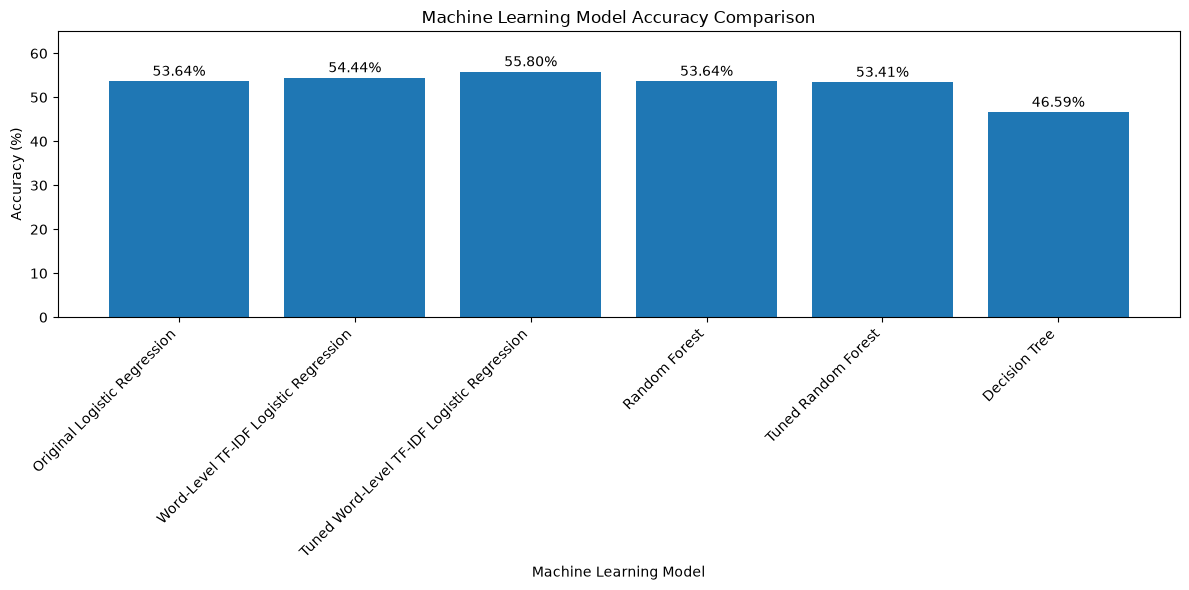

In [42]:
# Prepare model names and accuracy values
model_names = final_model_results["Model"]
accuracy_values = final_model_results["Accuracy (%)"]

# Create accuracy comparison chart
plt.figure(figsize=(12, 6))

bars = plt.bar(
    model_names,
    accuracy_values
)

# Add accuracy values on top of each bar
for bar, value in zip(bars, accuracy_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.title("Machine Learning Model Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 65)
plt.tight_layout()
plt.show()

## Final Model Evaluation Metrics

The final Tuned Word-Level TF-IDF Logistic Regression model is evaluated using accuracy, precision, recall, and F1-score.

These metrics provide a more detailed understanding of the model's classification performance, particularly because the Netflix audience rating dataset contains imbalanced rating categories.

Accuracy provides an overall measure of correct predictions, while precision, recall, and F1-score provide category-level insights into the model's ability to correctly identify different audience rating categories.


In [43]:
# Calculate overall evaluation metrics
final_accuracy = accuracy_score(
    y_test_text,
    y_pred_final
)

final_report = classification_report(
    y_test_text,
    y_pred_final,
    output_dict=True,
    zero_division=0
)

macro_precision = final_report["macro avg"]["precision"]
macro_recall = final_report["macro avg"]["recall"]
macro_f1 = final_report["macro avg"]["f1-score"]

weighted_precision = final_report["weighted avg"]["precision"]
weighted_recall = final_report["weighted avg"]["recall"]
weighted_f1 = final_report["weighted avg"]["f1-score"]

# Create summary table
final_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1-Score",
        "Weighted Precision",
        "Weighted Recall",
        "Weighted F1-Score"
    ],
    "Score": [
        final_accuracy,
        macro_precision,
        macro_recall,
        macro_f1,
        weighted_precision,
        weighted_recall,
        weighted_f1
    ]
})

# Convert scores to percentages
final_metrics["Score (%)"] = (
    final_metrics["Score"] * 100
).round(2)

print("Final Model Evaluation Metrics:")
display(final_metrics)

Final Model Evaluation Metrics:


,Metric,Score,Score (%)
0,Accuracy,0.558020,55.80
1,Macro Precision,0.340704,34.07
2,Macro Recall,0.308022,30.80
3,Macro F1-Score,0.304954,30.50
4,Weighted Precision,0.531775,53.18
5,Weighted Recall,0.558020,55.80
6,Weighted F1-Score,0.531945,53.19


## Final Model Strengths and Limitations

The final Tuned Word-Level TF-IDF Logistic Regression model demonstrates that TF-IDF-based text representation can capture useful patterns from Netflix content metadata for audience rating classification.

The model achieved the **highest observed test accuracy of 55.80%** among the evaluated approaches. However, its performance varies across rating categories due to class imbalance and the limited number of examples available for some rating categories.

### Strengths

* Achieved the highest observed test accuracy among the evaluated models.
* TF-IDF successfully converted Netflix content metadata into numerical features suitable for classification.
* Hyperparameter tuning improved the observed performance of the Logistic Regression model.
* The model showed stronger performance on frequently represented categories, particularly TV-MA, TV-14, and R.
* The approach is computationally practical and suitable for text-based multi-class classification.

### Limitations

* The dataset contains significant class imbalance across audience rating categories.
* Rare categories such as G, NC-17, NR, TV-Y7-FV, and UR have very few examples.
* The model has difficulty distinguishing between closely related categories, particularly TV-14 and TV-MA.
* The current approach relies primarily on content metadata and does not use advanced semantic representations such as transformer-based embeddings.
* The observed accuracy of 55.80% indicates that further improvements in feature representation, class balancing, and model optimization may be possible.


In [ ]:
print("FINAL MODEL STRENGTHS AND LIMITATIONS")
print("=" * 50)

print("\nFinal Model:")
print("Tuned Word-Level TF-IDF Logistic Regression")

print("\nTest Accuracy:")
print(f"{final_accuracy * 100:.2f}%")

print("\nKey Strengths:")
print("1. Highest accuracy among all evaluated models.")
print("2. Effective use of TF-IDF text features.")
print("3. Improved performance through hyperparameter tuning.")
print("4. Good performance on frequently represented rating categories.")

print("\nKey Limitations:")
print("1. Significant class imbalance is present.")
print("2. Rare rating categories are difficult to classify.")
print("3. TV-14 and TV-MA are frequently confused.")
print("4. Further feature engineering and advanced models could improve performance.")

## Final Conclusion

In this project, we developed a machine learning-based Netflix Audience Rating Classification system to predict audience rating categories from available Netflix content metadata.

Several machine learning approaches were evaluated, including Logistic Regression, TF-IDF-based Logistic Regression, Random Forest, tuned Random Forest, and Decision Tree. Different feature engineering and TF-IDF configurations were also tested to improve classification performance.

The original Logistic Regression model achieved an accuracy of **53.64%**. After applying Word-Level TF-IDF feature engineering and hyperparameter tuning, the final Tuned Word-Level TF-IDF Logistic Regression model achieved the **highest observed test accuracy of 55.80%** among the evaluated models. Random Forest achieved **53.64%**, tuned Random Forest achieved **53.41%**, and Decision Tree achieved **46.59%**.

The final model performed better on frequently represented rating categories such as **TV-MA, TV-14, and R**. However, rare rating categories remained difficult to classify because of the significant class imbalance in the dataset. The prediction analysis also showed that **TV-14 and TV-MA** were the most frequently confused categories.

Overall, the project demonstrates a complete machine learning classification workflow, including data preprocessing, exploratory analysis, feature engineering, TF-IDF vectorization, model training, hyperparameter tuning, evaluation, confusion matrix analysis, and comparative model analysis. The results highlight the usefulness of TF-IDF-based feature representation while also showing the challenges of multi-class classification with imbalanced rating categories.


In [44]:
print("TASK 3 - FINAL CONCLUSION")

print("=" * 50)

print("\nFinal Model:")
print("Tuned Word-Level TF-IDF Logistic Regression")

print(f"\nFinal Test Accuracy: {final_accuracy * 100:.2f}%")

print("\nModels Evaluated:")
print("- Logistic Regression")
print("- Random Forest")
print("- Tuned Random Forest")
print("- Decision Tree")
print("- Word-Level TF-IDF Logistic Regression")
print("- Tuned Word-Level TF-IDF Logistic Regression")

print("\nBest Result:")
print("Tuned Word-Level TF-IDF Logistic Regression")
print(f"Accuracy: {final_accuracy * 100:.2f}%")

print("\nConclusion:")
print(
    "TF-IDF-based Logistic Regression provided the highest observed "
    "test accuracy among the evaluated models, achieving 55.80% accuracy."
)

TASK 3 - FINAL CONCLUSION

Final Model:
Tuned Word-Level TF-IDF Logistic Regression

Final Test Accuracy: 55.80%

Models Evaluated:
- Logistic Regression
- Random Forest
- Tuned Random Forest
- Decision Tree
- Word-Level TF-IDF Logistic Regression
- Tuned Word-Level TF-IDF Logistic Regression

Best Result:
Tuned Word-Level TF-IDF Logistic Regression
Accuracy: 55.80%

Conclusion:
TF-IDF-based Logistic Regression provided the highest observed test accuracy among the evaluated models, achieving 55.80% accuracy.


## Future Improvements

Although the final model achieved the **highest observed test accuracy of 55.80%**, several improvements can be explored to enhance classification performance in future work.

### 1. Address Class Imbalance

Class imbalance can be handled using techniques such as oversampling, undersampling, or synthetic data generation. These approaches may improve the prediction of rare audience rating categories.

### 2. Use Advanced Text Representations

Pre-trained language models and contextual embeddings could capture deeper semantic relationships in Netflix metadata compared with traditional TF-IDF features.

### 3. Feature Engineering

Additional meaningful features could be created from the available metadata, such as genre frequency, director information, country patterns, release-year groups, and duration categories.

### 4. Try Additional Machine Learning Models

Other classification algorithms such as Support Vector Machines, Gradient Boosting, XGBoost, or LightGBM could be evaluated to determine whether they provide better performance.

### 5. Improve Data Quality

Rare and inconsistent rating categories could be reviewed and standardized where appropriate. Additional data could also provide more training examples for underrepresented classes.

### 6. Hyperparameter Optimization

A broader hyperparameter search could be performed using techniques such as RandomizedSearchCV or Bayesian optimization to identify potentially better model configurations.

### 7. Ensemble Methods

Multiple strong classifiers could be combined using ensemble techniques to potentially improve prediction stability and overall classification performance.


## Final Project Summary

The Netflix Audience Rating Classification project successfully implemented a complete machine learning classification workflow using Netflix content metadata.

The dataset was prepared by handling missing values, selecting relevant features, and splitting the data into training and testing sets. Multiple machine learning models were then trained, tuned, and evaluated using appropriate classification metrics.

Word-Level TF-IDF feature engineering improved the performance of Logistic Regression compared with the original preprocessing approach. Hyperparameter tuning further improved the observed test performance, resulting in the highest observed test accuracy of **55.80%**.

### Final Results

| Model                                       | Test Accuracy |
| ------------------------------------------- | ------------: |
| Tuned Word-Level TF-IDF Logistic Regression |    **55.80%** |
| Word-Level TF-IDF Logistic Regression       |        54.44% |
| Original Logistic Regression                |        53.64% |
| Random Forest                               |        53.64% |
| Tuned Random Forest                         |        53.41% |
| Decision Tree                               |        46.59% |

### Final Model

**Tuned Word-Level TF-IDF Logistic Regression**

* TF-IDF N-gram Range: `(1, 2)`
* C: `2`
* Solver: `saga`
* Maximum Iterations: `3000`
* Test Accuracy: **55.80%**

The final evaluation also showed that the model performed better on frequently represented rating categories, while rare categories remained challenging due to significant class imbalance. The most frequent classification errors occurred between **TV-14 and TV-MA**.
